In [1]:
from homicsx import(
    GeometryInput, 
    PhysicalTags, 
    MeshSettings, 
    LinearElasticIsotropic, 
    MaterialAssignment, 
    ProblemSettings
)
from homicsx.stochastic import perform_ensemble_study

Preparing geometry input for 2D mono-disperse unit-cell geometry with spherical inclusions

In [2]:
geometry_input = GeometryInput(
    dim=2,
    dispersion="mono",
    volume_fraction=0.2,
    num_particles=30,
    clearance=0.015,
    domain_size=(1, 1),
    shape="circle",
)

Preparing physical tagging convention and mesh settings

In [3]:
physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.025,
    max_size=0.035,
    physical_tags=physical_tags,
)

Defining the material assignment

In [4]:
E_mat = 1.0
nu_mat = 0.3
mat_matrix = LinearElasticIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 100.0
nu_inc = 0.3
mat_particle = LinearElasticIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

Preparing the FEM solver settings

In [5]:
fem_settings = ProblemSettings(
    dim = geometry_input.dim,
    kinematics='small_strain',
    two_dimensional_formulation='plane_strain',
    element_family='Lagrange',
    element_degree=1,
    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
)

Performing ensemble study

In [6]:
ensemble_solution = perform_ensemble_study (
    ensemble_size=100,
    geometry_input=geometry_input,
    mesh_settings=mesh_settings,
    Physical_tags=physical_tags,
    assignment=material_assignment,
    fem_settings=fem_settings,
    matrix_phase_id=0,
    homogenization_solver="linear",
    homogenization_mode="partial",
)

Printing the ensemble result summary

In [7]:
ensemble_solution.print_summary()

---------------- Ensemble Study Summary -----------------
C_hom component statistics:
Mean:
[[1.838 0.748 0.   ]
 [0.748 1.838 0.   ]
 [0.    0.    0.547]]


Variance:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


Standard deviation:
[[0.013 0.009 0.   ]
 [0.009 0.013 0.   ]
 [0.    0.    0.005]]


Max:
[[1.884 0.8   0.   ]
 [0.8   1.884 0.   ]
 [0.    0.    0.567]]


Min:
[[1.808 0.732 0.   ]
 [0.732 1.808 0.   ]
 [0.    0.    0.536]]


Engineering moduli statistics: 
Mean: 
    kappa:  1.295050763654487
    mu:     0.5467390290032603
    E:      1.537740673612434
    nu:     0.4062914280758975


Variance: 
    kappa:  0.0001741021487571978
    mu:     2.9346394133039875e-05
    E:      0.00021509116019425211
    nu:     7.078425270488064e-06


Standard deviation: 
    kappa:  0.013194777328822105
    mu:     0.005417231223885489
    E:      0.01466598650600266
    nu:     0.0026605310128784564


Max: 
    kappa:  1.3503652060842977
    mu:     0.5667790388578656
    E:      1.58653103486296

Visualizing the result moduli as a histogram chart

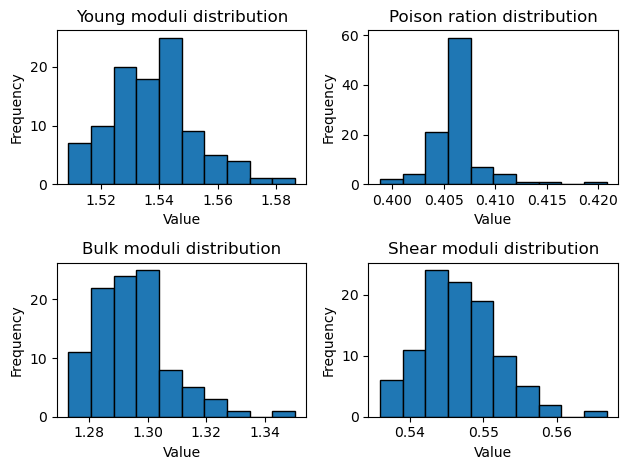

In [8]:
ensemble_solution.visualize_moduli_histogram(num_bins=10)